1 : Importations et téléchargements

In [3]:
#importation les bibliothéques nécessaires
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Téléchargement des packages NLTK nécessaires
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

2 : Chargement des données nettoyées

In [4]:
# Chargement les données
df_enron = pd.read_csv('../data/enron_clean.csv')

# Afficher les premières lignes pour vérifier
df_enron.head()

,Spam/Ham,clean_text
0,ham,christmas tree farm pictures
1,ham,"vastar resources , inc . gary , production fro..."
2,ham,calpine daily gas nomination - calpine daily g...
3,ham,re : issue fyi - see note below - already done...
4,ham,meter 7268 nov allocation fyi .\n- - - - - - -...


3:La fonction de prétraitement

In [5]:
# Définition des stopwords en anglais
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Fonction pour prétraiter le texte :
    1. Convertir en minuscules.
    2. Supprimer la ponctuation.
    3. Tokenizer et supprimer les stopwords.
    """
    # Sécurité : s'assurer que l'entrée est bien lue comme du texte
    text = str(text)
    
    text = text.lower()
    text = ''.join([char for char in text if char not in string.punctuation])
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    
    return ' '.join(tokens)

4 : Application du traitement

In [6]:
print("Début du prétraitement du texte...")

# On crée une nouvelle colonne 'text_preprocessed' en appliquant ta fonction
df_enron['text_preprocessed'] = df_enron['clean_text'].apply(preprocess_text)

print("✅ Prétraitement terminé !")
df_enron[['clean_text', 'text_preprocessed']].head() # Comparaison avant/après

Début du prétraitement du texte...
✅ Prétraitement terminé !


,clean_text,text_preprocessed
0,christmas tree farm pictures,christmas tree farm pictures
1,"vastar resources , inc . gary , production fro...",vastar resources inc gary production high isla...
2,calpine daily gas nomination - calpine daily g...,calpine daily gas nomination calpine daily gas...
3,re : issue fyi - see note below - already done...,issue fyi see note already done stella forward...
4,meter 7268 nov allocation fyi .\n- - - - - - -...,meter 7268 nov allocation fyi forwarded lauri ...


5 : Encodage de la cible (Spam/Ham)

In [7]:
 

# Transformer spam en 1 et ham en 0
df_enron['Spam/Ham'] = df_enron['Spam/Ham'].map({'spam': 1, 'ham': 0})
#Afficher 
df_enron.head()


,Spam/Ham,clean_text,text_preprocessed
0,0,christmas tree farm pictures,christmas tree farm pictures
1,0,"vastar resources , inc . gary , production fro...",vastar resources inc gary production high isla...
2,0,calpine daily gas nomination - calpine daily g...,calpine daily gas nomination calpine daily gas...
3,0,re : issue fyi - see note below - already done...,issue fyi see note already done stella forward...
4,0,meter 7268 nov allocation fyi .\n- - - - - - -...,meter 7268 nov allocation fyi forwarded lauri ...


6:Sauvegarder

In [8]:
#Supprimer la colonne "clean_text"
df_enron = df_enron.drop(columns=['clean_text'])
#Afficher
df_enron.head()

,Spam/Ham,text_preprocessed
0,0,christmas tree farm pictures
1,0,vastar resources inc gary production high isla...
2,0,calpine daily gas nomination calpine daily gas...
3,0,issue fyi see note already done stella forward...
4,0,meter 7268 nov allocation fyi forwarded lauri ...


In [ ]:
#Sauvegarder le dataset final
chemin_sauvegarde = '../data/enron_preprocessed.csv'
df_enron.to_csv(chemin_sauvegarde, index=False)
print("✅ Colonne 'clean_text' supprimée.")
print(f"✅ Fichier final sauvegardé : {chemin_sauvegarde}")
print(f"Colonnes restantes : {df_enron.columns.tolist()}")
df_enron.head()

'#Sauvegarder le dataset final\nchemin_sauvegarde = \'../data/enron_preprocessed.csv\'\ndf_enron.to_csv(chemin_sauvegarde, index=False)\nprint("✅ Colonne \'clean_text\' supprimée.")\nprint(f"✅ Fichier final sauvegardé : {chemin_sauvegarde}")\nprint(f"Colonnes restantes : {df_enron.columns.tolist()}")\ndf_enron.head()'

**Les WordClouds**

In [10]:
# 1. Préparation des mots pour les Ham (Emails normaux)

ham_words = ' '.join(df_enron[df_enron['Spam/Ham'] == 0]['text_preprocessed'].astype(str))
wordcloud_ham = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(ham_words)

In [ ]:
# 2. Préparation des mots pour les Spam

spam_words = ' '.join(df_enron[df_enron['Spam/Ham'] == 1]['text_preprocessed'].astype(str))
wordcloud_spam = WordCloud(width=800, height=400, background_color='black', colormap='Reds', max_words=100).generate(spam_words)

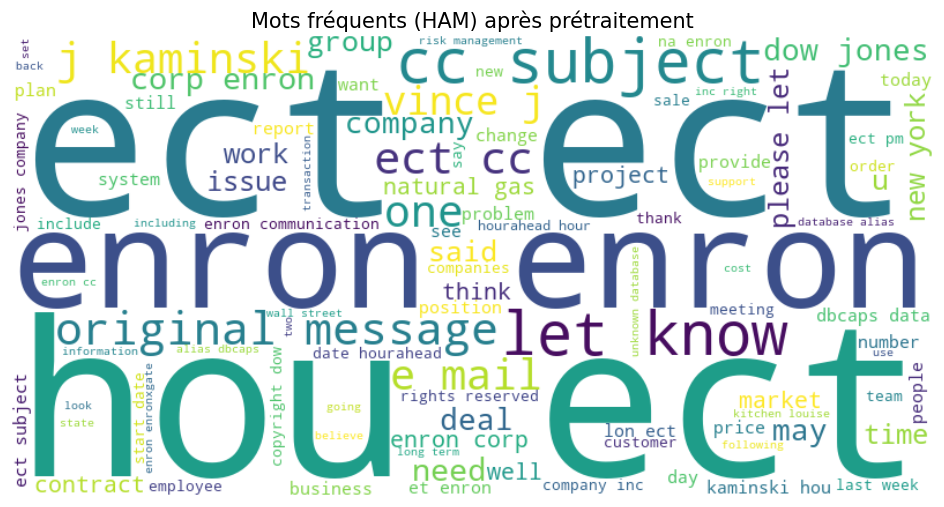

In [12]:
# --- Affichage et Sauvegarde : HAM ---
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_ham, interpolation='bilinear')
plt.title('Mots fréquents (HAM) après prétraitement', fontsize=15)
plt.axis('off')
plt.savefig('../resultats/05_wordcloud_ham_clean.png', bbox_inches='tight', dpi=300)
plt.show()

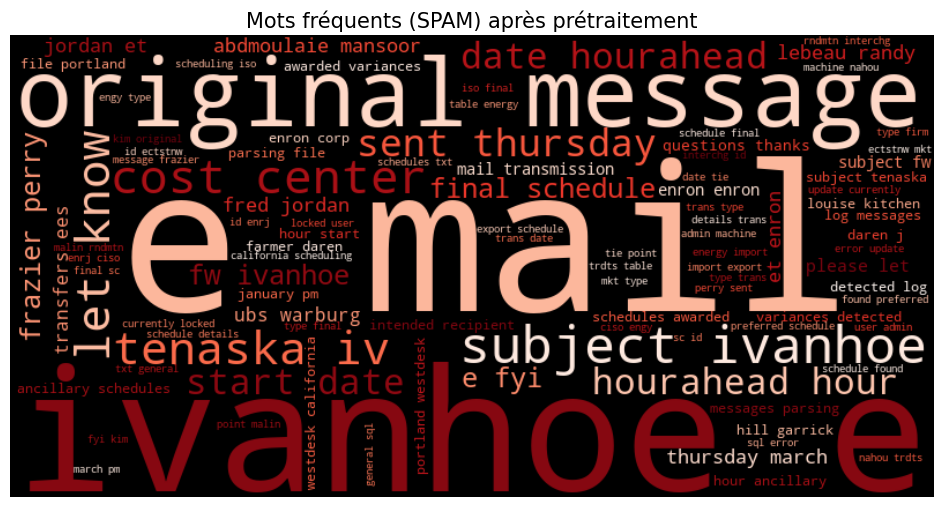

In [13]:
# --- Affichage et Sauvegarde : SPAM ---
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_spam, interpolation='bilinear')
plt.title('Mots fréquents (SPAM) après prétraitement', fontsize=15)
plt.axis('off')
plt.savefig('../resultats/06_wordcloud_spam_clean.png', bbox_inches='tight', dpi=300)
plt.show()